In [1]:
import pandas as pd

# 파일 경로 설정
file_path = 'pos_data_전처리완료_final.parquet'

print("데이터 로딩을 시작합니다. 약 1억 행의 데이터이므로 메모리 사용량에 주의하세요...")

try:
    # 전체 데이터를 df_pos로 로드
    df_pos = pd.read_parquet(file_path)
    print("데이터 로드 성공!")
    
    # 데이터 정보 확인
    print(f"\n전체 데이터 행 수: {len(df_pos):,}")
    display(df_pos.head())
    
    print("\n--- 데이터 기본 정보 ---")
    print(df_pos.info())
    
    print("\n--- 컬럼별 결측치 확인 ---")
    print(df_pos.isnull().sum())
    
except MemoryError:
    print("\n[오류] 메모리 부족으로 전체 데이터를 로드할 수 없습니다. RAM 용량을 확인하거나 샘플링 또는 청크 방식을 사용하세요.")


데이터 로딩을 시작합니다. 약 1억 행의 데이터이므로 메모리 사용량에 주의하세요...
데이터 로드 성공!

전체 데이터 행 수: 100,076,147


,영업일자,판매시분초,점포코드,POS번호,거래번호,상품코드,매출수량,매출금액,상품명,상품대분류명,상품중분류명,상품소분류명,판매시간_dt,판매월,판매주,판매일,판매시간대,판매요일,거래_고유키
0,20250523,84531,64139,2,26651,314952,1.0,500.0,K)릴 하이브리드용 액상카트리지,담배,전자담배용 주변기기,KT&G 주변기기,2025-05-23 08:45:31,5,21,23,8,금,20250523_64139_2_26651
1,20250523,105724,52657,1,48727,314954,10.0,45000.0,K)MIIX 믹스(릴 하이브리드),담배,국산담배,KT&G(전자담배용 담배),2025-05-23 10:57:24,5,21,23,10,금,20250523_52657_1_48727
2,20250523,105724,52657,1,48727,314952,10.0,5000.0,K)릴 하이브리드용 액상카트리지,담배,전자담배용 주변기기,KT&G 주변기기,2025-05-23 10:57:24,5,21,23,10,금,20250523_52657_1_48727
3,20250523,84531,64139,2,26651,314983,1.0,4500.0,K)MIIX 아이스더블,담배,국산담배,KT&G(전자담배용 담배),2025-05-23 08:45:31,5,21,23,8,금,20250523_64139_2_26651
4,20250523,83823,50134,1,67971,314988,1.0,4500.0,K)에쎄 히말라야1mg,담배,국산담배,KT&G(일반담배),2025-05-23 08:38:23,5,21,23,8,금,20250523_50134_1_67971



--- 데이터 기본 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100076147 entries, 0 to 100076146
Data columns (total 19 columns):
 #   Column   Dtype         
---  ------   -----         
 0   영업일자     int64         
 1   판매시분초    int64         
 2   점포코드     int64         
 3   POS번호    int64         
 4   거래번호     int64         
 5   상품코드     object        
 6   매출수량     float32       
 7   매출금액     float32       
 8   상품명      object        
 9   상품대분류명   object        
 10  상품중분류명   object        
 11  상품소분류명   object        
 12  판매시간_dt  datetime64[ns]
 13  판매월      Int8          
 14  판매주      Int8          
 15  판매일      Int8          
 16  판매시간대    Int8          
 17  판매요일     category      
 18  거래_고유키   object        
dtypes: Int8(4), category(1), datetime64[ns](1), float32(2), int64(5), object(6)
memory usage: 10.5+ GB
None

--- 컬럼별 결측치 확인 ---
영업일자       0
판매시분초      0
점포코드       0
POS번호      0
거래번호       0
상품코드       0
매출수량       0
매출금액       0
상품명        0
상품대분류명   

## '매출금액' 이상치 확인

In [2]:
df_pos['매출금액'].describe()

count    1.000761e+08
mean     3.322680e+03
std      2.603126e+05
min     -1.300000e+09
25%      1.500000e+03
50%      2.300000e+03
75%      4.500000e+03
max      1.300000e+09
Name: 매출금액, dtype: float64

Q3(75% 지점): 4,500원
Q3 초과 데이터 수: 15,554,551건 (전체의 15.54%)

--- Q3 초과 구간 수치 분포 ---
count     1.555455e+07
mean      1.004214e+04
std       4.671064e+05
min       4.501000e+03
50%       6.900000e+03
75%       9.600000e+03
90%       1.500000e+04
99%       4.800000e+04
99.9%     1.350000e+05
99.99%    4.950000e+05
max       1.300000e+09
Name: 매출금액, dtype: float64


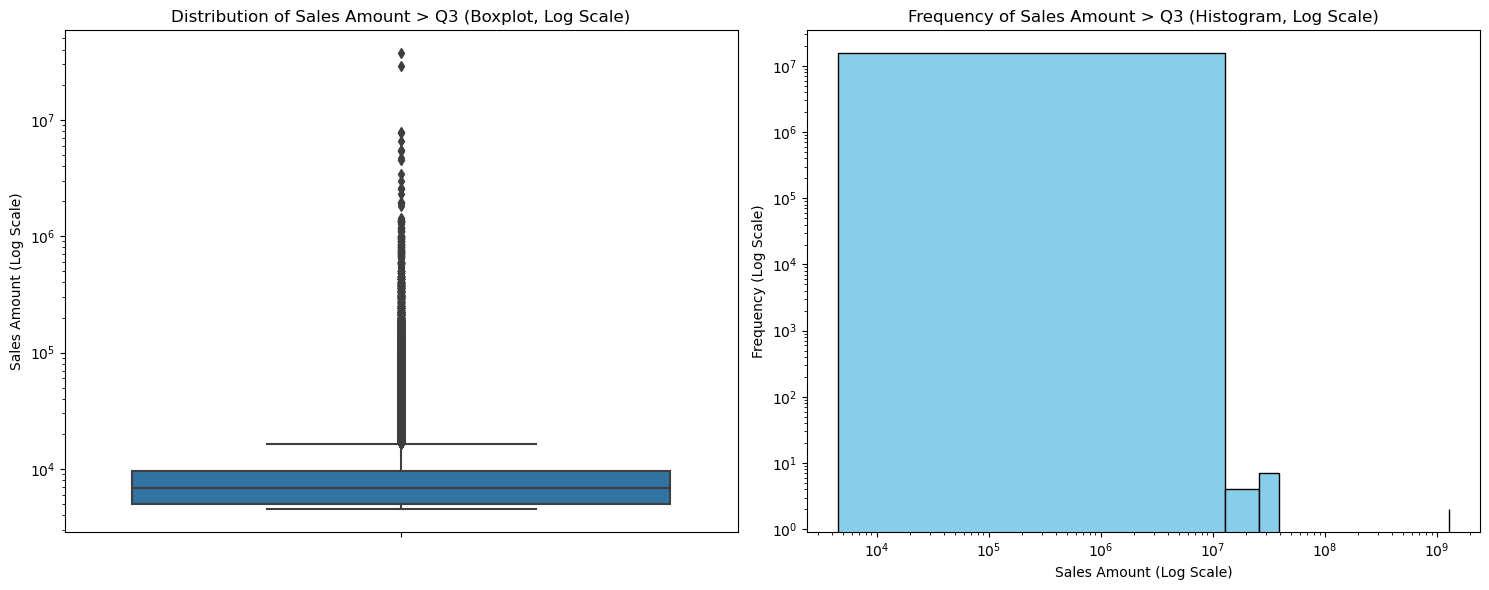

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Q3 값 설정 (이전 describe 결과 기반)
q3 = df_pos['매출금액'].quantile(0.75)
print(f"Q3(75% 지점): {q3:,.0f}원")

# 2. Q3를 초과하는 데이터 필터링
df_over_q3 = df_pos[df_pos['매출금액'] > q3]

print(f"Q3 초과 데이터 수: {len(df_over_q3):,}건 (전체의 {len(df_over_q3)/len(df_pos)*100:.2f}%)")

# 3. 수치적 분포 확인 (상위 1%, 0.1%, 0.01% 등 극단값 위주)
print("\n--- Q3 초과 구간 수치 분포 ---")
print(df_over_q3['매출금액'].describe(percentiles=[.5, .75, .9, .99, .999, .9999]))

# 4. 시각적 분포 확인
plt.figure(figsize=(15, 6))

# (1) Boxplot: 전체적인 퍼짐 정도 확인 (샘플링 100만 건)
plt.subplot(1, 2, 1)
sns.boxplot(y=df_over_q3['매출금액'].sample(n=min(1000000, len(df_over_q3))))
plt.yscale('log')  # 극단값 때문에 로그 스케일 필수
plt.title('Distribution of Sales Amount > Q3 (Boxplot, Log Scale)')
plt.ylabel('Sales Amount (Log Scale)')

# (2) Histogram: 구간별 빈도 확인
plt.subplot(1, 2, 2)
plt.hist(df_over_q3['매출금액'], bins=100, color='skyblue', edgecolor='black')
plt.yscale('log')
plt.xscale('log')
plt.title('Frequency of Sales Amount > Q3 (Histogram, Log Scale)')
plt.xlabel('Sales Amount (Log Scale)')
plt.ylabel('Frequency (Log Scale)')

plt.tight_layout()
plt.show()

## 객단가(매출금액/매출수량) 확인

객단가 계산 및 분포 확인을 시작합니다...

--- 객단가(Unit Price) 수치 요약 ---
count     1.000761e+08
mean      2.689671e+03
std       4.914409e+03
min       1.000000e+00
25%       1.300000e+03
50%       2.000000e+03
75%       3.500000e+03
95%       4.900000e+03
99%       1.080000e+04
99.9%     3.900000e+04
99.99%    1.199000e+05
max       1.300000e+07
Name: 객단가, dtype: float64

--- 객단가 상위 20개 항목 (고가 상품 혹은 오류 확인) ---


,상품명,상품대분류명,매출수량,매출금액,객단가
46815837,윌리엄)글렌피딕 40년,양주와인,-100.0,-1.300000e+09,13000000.0
46815838,윌리엄)글렌피딕 40년,양주와인,100.0,1.300000e+09,13000000.0
46815873,윌리엄)글렌피딕 40년,양주와인,100.0,1.300000e+09,13000000.0
46815874,윌리엄)글렌피딕 40년,양주와인,-100.0,-1.300000e+09,13000000.0
98874147,25추)골드바 37.5g,서비스 상품,1.0,7.320000e+06,7320000.0
90354738,25추)골드바 37.5g,서비스 상품,1.0,7.320000e+06,7320000.0
73425259,25추)골드바 37.5g,서비스 상품,1.0,7.320000e+06,7320000.0
51078776,25추)골드바 37.5g,서비스 상품,1.0,6.780000e+06,6780000.0
1823817,25설)골드바37.5g,서비스 상품,1.0,5.626000e+06,5626000.0
47138733,25설)골드바37.5g,서비스 상품,1.0,5.548000e+06,5548000.0



시각화를 생성 중입니다...


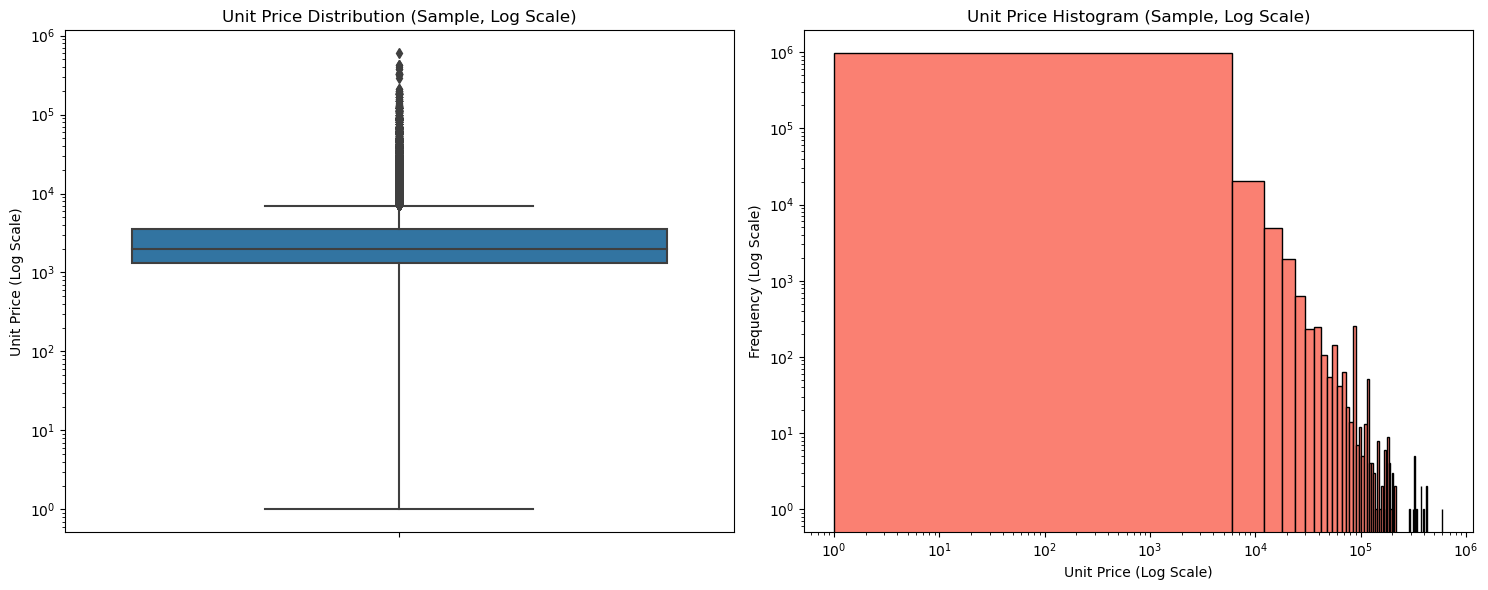

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("객단가 계산 및 분포 확인을 시작합니다...")

# 1. 객단가 계산 (메모리 절약을 위해 float32 사용, 0으로 나누기 방지)
df_pos['객단가'] = (df_pos['매출금액'] / df_pos['매출수량'].replace(0, np.nan)).astype('float32')

# 2. 수치 요약
print("\n--- 객단가(Unit Price) 수치 요약 ---")
print(df_pos['객단가'].describe(percentiles=[.25, .5, .75, .95, .99, .999, .9999]))

# 3. 극단적 객단가 상위 20개 확인 (데이터 입력 오류 탐색용)
print("\n--- 객단가 상위 20개 항목 (고가 상품 혹은 오류 확인) ---")
top_prices = df_pos[['상품명', '상품대분류명', '매출수량', '매출금액', '객단가']].sort_values(by='객단가', ascending=False).head(20)
display(top_prices)

# 4. 시각화 (메모리 보호를 위해 100만 건 샘플링)
print("\n시각화를 생성 중입니다...")
df_sample = df_pos['객단가'].sample(n=min(1000000, len(df_pos)), random_state=2026).dropna()

plt.figure(figsize=(15, 6))

# (1) Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(y=df_sample)
plt.yscale('log')
plt.title('Unit Price Distribution (Sample, Log Scale)')
plt.ylabel('Unit Price (Log Scale)')

# (2) Histogram
plt.subplot(1, 2, 2)
plt.hist(df_sample, bins=100, color='salmon', edgecolor='black')
plt.yscale('log')
plt.xscale('log')
plt.title('Unit Price Histogram (Sample, Log Scale)')
plt.xlabel('Unit Price (Log Scale)')
plt.ylabel('Frequency (Log Scale)')

plt.tight_layout()
plt.show()

## (대분류 = 식품) 거래 데이터만 남겨보기

In [5]:
df_pos['상품대분류명'].value_counts()

상품대분류명
음료         18980084
담배         17535543
과자         13361428
유음료         9061196
미반          6128623
면           4927105
서비스 상품      3384264
냉장          2763112
맥주          2480144
즉석음료        2455038
빵           2203522
전통주         2038667
아이스크림       2028364
일용잡화        1881160
조리빵         1470131
즉석 식품       1250121
약품/의료품      1033634
건강/기호식품      926650
가공식품         760780
위생용품         743742
양주와인         685984
디저트          623139
안주           580616
H&B          574087
신선           539930
가정용품         374757
문구/완구        364830
미용/화장품       272164
간식           191805
패션잡화         171660
조미료/건물       135300
냉동           106771
미디어 상품        41771
기타               24
소모품               1
Name: count, dtype: int64

In [3]:
import gc

# 1. 필터링할 식품 카테고리 리스트 (검색 속도를 위해 set으로 감쌌습니다)
food_categories = set([
    '음료', '과자', '유음료', '미반', '면', '냉장', '맥주', '즉석음료', '빵', '전통주', 
    '아이스크림', '조리빵', '즉석 식품', '건강/기호식품', '가공식품', '양주와인', '디저트', 
    '안주', '신선', '간식', '조미료/건물', '냉동'
])

print("상품대분류명 공백 제거 중...")
df_pos['상품대분류명'] = df_pos['상품대분류명'].str.strip()

print("식품이 아닌 행을 찾아 삭제 중입니다 (메모리 절약 In-place 방식)...")
# 2. 버려야 할 데이터(식품이 아닌 것)의 인덱스 번호를 찾습니다.
drop_indices = df_pos[~df_pos['상품대분류명'].isin(food_categories)].index

# 3. 데이터프레임을 새로 복사하지 않고, 기존 프레임에서 해당 인덱스 행만 날려버립니다.
df_pos.drop(drop_indices, inplace=True)
gc.collect()  # 삭제 직후 즉시 가비지 컬렉터로 메모리 회수

# 4. 직관성을 위해 변수 이름을 붙여줍니다 (데이터는 복사되지 않고 이름표만 달립니다)
df_pos_food = df_pos

del drop_indices
gc.collect()

# 5. 결과 확인
print(f"\n식품 카테고리 필터링 완료!")
print(f"남은 식품 카테고리 행 수: {len(df_pos_food):,}")

display(df_pos_food.head())

상품대분류명 공백 제거 중...
식품이 아닌 행을 찾아 삭제 중입니다 (메모리 절약 In-place 방식)...

식품 카테고리 필터링 완료!
남은 식품 카테고리 행 수: 73,698,510


,영업일자,판매시분초,점포코드,POS번호,거래번호,상품코드,매출수량,매출금액,상품명,상품대분류명,상품중분류명,상품소분류명,판매시간_dt,판매월,판매주,판매일,판매시간대,판매요일,거래_고유키,객단가
14,20250523,84822,12611,1,13164,202316,1.0,1000.0,오리온)제주용암수530ml,음료,생수,500ml이하,2025-05-23 08:48:22,5,21,23,8,금,20250523_12611_1_13164,1000.0
15,20250523,143425,17796,1,59106,117969,1.0,1200.0,오리온)고소미70g,과자,비스킷류,크래커,2025-05-23 14:34:25,5,21,23,14,금,20250523_17796_1_59106,1200.0
16,20250523,145747,54630,2,3156,124518,1.0,1200.0,오리온)코코망고알맹이67g,과자,젤리류,국산젤리,2025-05-23 14:57:47,5,21,23,14,금,20250523_54630_2_3156,1200.0
17,20250523,165556,18467,1,491,116368,1.0,1700.0,오리온)꼬북칩콘스프맛80g,과자,스낵류,옥수수스낵,2025-05-23 16:55:56,5,21,23,16,금,20250523_18467_1_491,1700.0
18,20250523,165556,18467,1,491,117048,1.0,1700.0,오리온)태양의맛썬핫스파이시80g,과자,스낵류,옥수수스낵,2025-05-23 16:55:56,5,21,23,16,금,20250523_18467_1_491,1700.0


In [6]:
# 1. 카테고리별 요약 통계 (매출금액, 매출수량, 객단가)
print("카테고리별 요약 통계를 계산 중입니다... (데이터가 커서 시간이 소요될 수 있습니다)")

# 요약 통계량 확인 (평균, 최대값, 99% 지점 등)
category_summary = df_pos_food.groupby('상품대분류명')[['매출금액', '매출수량', '객단가']].agg(['mean', 'max', 'std', lambda x: x.quantile(0.99)])
category_summary.columns = [f"{col}_{stat}" for col, stat in [('매출금액','mean'), ('매출금액','max'), ('매출금액','std'), ('매출금액','99%'), 
                                                       ('매출수량','mean'), ('매출수량','max'), ('매출수량','std'), ('매출수량','99%'),
                                                       ('객단가','mean'), ('객단가','max'), ('객단가','std'), ('객단가','99%')]]

display(category_summary)

# 2. 카테고리별 객단가 상위 5개 상품 확인 (이상치 판단용)
print("\n--- 카테고리별 객단가 상위 상품 리스트 (데이터 오류 확인) ---")

for cat in food_categories:
    print(f"\n[카테고리: {cat}]")
    # 해당 카테고리 추출
    subset = df_pos_food[df_pos_food['상품대분류명'] == cat]
    
    # 객단가 기준 내림차순 상위 5개
    top_items = subset[['상품명', '상품중분류명', '매출수량', '매출금액', '객단가']].sort_values(by='객단가', ascending=False).head(5)
    display(top_items)

print("\n모든 카테고리 확인이 완료되었습니다. 위 리스트를 보고 비상식적인 가격(예: 껌 한 통에 100만원 등)을 가진 카테고리와 상품을 선별하세요.")

카테고리별 요약 통계를 계산 중입니다... (데이터가 커서 시간이 소요될 수 있습니다)


,매출금액_mean,매출금액_max,매출금액_std,매출금액_99%,매출수량_mean,매출수량_max,매출수량_std,매출수량_99%,객단가_mean,객단가_max,객단가_std,객단가_99%
상품대분류명,,,,,,,,,,,,
가공식품,3980.633057,2.897100e+07,9.736688e+04,12600.0,1.304172,999.0,3.884740,4.0,3180.925781,76900.0,1892.556803,8900.0
간식,3392.411865,2.520000e+05,1.864179e+03,7000.0,0.970204,72.0,0.472518,2.0,3507.198242,5900.0,786.496735,5700.0
건강/기호식품,4476.406738,1.177600e+07,2.070079e+04,21200.0,1.764210,484.0,2.177320,8.0,2800.568115,132000.0,2615.370051,12500.0
과자,2047.958008,2.997000e+07,1.203996e+04,8000.0,1.138097,999.0,1.470065,4.0,1868.448364,104000.0,1270.037485,6000.0
냉동,5600.462891,5.283600e+06,3.366100e+04,15600.0,1.042053,60.0,0.822891,3.0,5428.298340,235000.0,5850.041804,11930.0
냉장,2998.763184,3.725200e+06,5.231662e+03,9900.0,1.235766,383.0,1.036915,3.0,2644.668701,100000.0,1403.731763,9000.0
디저트,3159.416504,6.262000e+05,3.701159e+03,16000.0,1.192573,210.0,1.066146,4.0,2678.080322,49000.0,1676.222579,4900.0
맥주,6316.251465,2.322600e+06,9.136040e+03,23450.0,1.917817,600.0,2.422791,6.0,3806.465088,65000.0,3016.801615,18000.0
면,1723.765015,8.400000e+05,1.703315e+03,5600.0,1.118279,570.0,1.087477,3.0,1569.119385,31000.0,665.151178,4750.0



--- 카테고리별 객단가 상위 상품 리스트 (데이터 오류 확인) ---

[카테고리: 건강/기호식품]


,상품명,상품중분류명,매출수량,매출금액,객단가
58539382,25추)정관장홍력환30환,선물세트,1.0,132000.0,132000.0
97824765,25추)정관장홍력환30환,선물세트,1.0,132000.0,132000.0
67717660,25추)정관장홍력환30환,선물세트,2.0,197000.0,98500.0
46512,25설)정관장홍력환30환,선물세트,1.0,96500.0,96500.0
56332542,25추)정관장홍력환30환,선물세트,1.0,90300.0,90300.0



[카테고리: 미반]


...


[카테고리: 조미료/건물]


,상품명,상품중분류명,매출수량,매출금액,객단가
59266908,25추_올가)참기름간장선물세트2호,선물세트,4.0,356000.0,89000.000000
61576503,25추_코주부)프리미엄육포세트600g,선물세트,11.0,850040.0,77276.367188
3190821,ORGA)저온로스팅견과앤베리5종혼합세트_25설,선물세트,1.0,77000.0,77000.000000
44537254,ORGA)저온로스팅견과앤베리5종혼합세트_25설,선물세트,1.0,77000.0,77000.000000
28111411,ORGA)저온로스팅견과앤베리5종혼합세트_25설,선물세트,-1.0,-77000.0,77000.000000



[카테고리: 신선]


,상품명,상품중분류명,매출수량,매출금액,객단가
55656319,한우 1++등급 명품세트 2.0kg,수축산/계란,1.0,499000.0,499000.0
22101122,25설)한우 1++ 프레지던트 세트 2.0kg,수축산/계란,1.0,498000.0,498000.0
69559040,민생)마블나인 1++등급구이혼합세트 2.6kg,수축산/계란,1.0,419000.0,419000.0
7229710,25설)한우 1++ 프레지던트 세트 2.0kg,수축산/계란,1.0,409500.0,409500.0
28972196,25설)Marble 9 (마블나인) 한우 구이세트 3호 2.0kg,수축산/계란,1.0,398000.0,398000.0



모든 카테고리 확인이 완료되었습니다. 위 리스트를 보고 비상식적인 가격(예: 껌 한 통에 100만원 등)을 가진 카테고리와 상품을 선별하세요.


### 추가적으로 확인해볼 것.

- 각 카테고리별로 매출수량 이상치 (99% 초과)
- 대분류 별로 객단가 q99 이상 제거

In [7]:
# 1. 카테고리별 매출수량 이상치 (99% 초과) 확인
print("[분석 1] 각 카테고리별 매출수량 99% 초과 데이터 확인 중...")

# 카테고리별 매출수량 99% 계산
qty_99_series = df_pos_food.groupby('상품대분류명')['매출수량'].quantile(0.99)

for cat in food_categories:
    q99_val = qty_99_series[cat]
    # 해당 카테고리에서 99%를 초과하는 데이터 추출
    qty_outliers = df_pos_food[(df_pos_food['상품대분류명'] == cat) & (df_pos_food['매출수량'] > q99_val)]
    
    if len(qty_outliers) > 0:
        print(f"\n[카테고리: {cat}] 매출수량 99%({q99_val}) 초과 건수: {len(qty_outliers):,}건")
        # 수량 기준 내림차순 상위 5개 출력
        display(qty_outliers[['상품명', '상품중분류명', '매출수량', '매출금액', '객단가']].sort_values(by='매출수량', ascending=False).head(5))

print("\n" + "="*50 + "\n")

[분석 1] 각 카테고리별 매출수량 99% 초과 데이터 확인 중...

[카테고리: 건강/기호식품] 매출수량 99%(8.0) 초과 건수: 6,831건


,상품명,상품중분류명,매출수량,매출금액,객단가
21873074,삼양사)상쾌환스틱샤인머스캣18g,숙취해소제,484.0,1887600.0,3900.0
86901046,PB)NEW한라봉유자차원컵45g,원컵,400.0,600000.0,1500.0
67023481,뉴트)비비랩밀크씨슬파워샷20ml,건강/이너뷰티,383.0,1493700.0,3900.0
72459323,삼양사)상쾌환3g,숙취해소제,323.0,936700.0,2900.0
32655699,삼양사)상쾌환스틱샤인머스캣18g,숙취해소제,300.0,1170000.0,3900.0



[카테고리: 미반] 매출수량 99%(2.0) 초과 건수: 9,202건


,상품명,상품중분류명,매출수량,매출금액,객단가
72884175,한도초과)기사식당 바싹불고기,도시락,900.0,4680000.0,5200.0
52058841,한도초과)기사식당 바싹불고기,도시락,900.0,4680000.0,5200.0
85243785,한도초과)기사식당 바싹불고기,도시락,900.0,4680000.0,5200.0
77377171,한도초과)기사식당 바싹불고기,도시락,474.0,2464800.0,5200.0
50935654,그린)맛장우맛자랑 반반제육,도시락,450.0,2475000.0,5500.0



[카테고리: 전통주] 매출수량 99%(5.0) 초과 건수: 17,458건


...

,상품명,상품중분류명,매출수량,매출금액,객단가
49067464,하이트)켈리500ml캔,국산맥주,600.0,1680000.0,2800.0
48233487,러비어스)프라가500ml캔,수입맥주,510.0,1020000.0,2000.0
47744136,비어)칭따오맥주500ml캔,수입맥주,500.0,2250000.0,4500.0
81891431,오비)카스500ml캔,국산맥주,484.0,1355200.0,2800.0
39461500,하이트)테라500ml캔,국산맥주,474.0,1327200.0,2800.0



[카테고리: 조미료/건물] 매출수량 99%(4.0) 초과 건수: 973건


,상품명,상품중분류명,매출수량,매출금액,객단가
97205282,동원)더바삭한김5g,건해산물,999.0,666000.0,666.666687
74572063,25추_LG)프리미엄햄복합3호,선물세트,978.0,37333520.0,38173.332031
83709037,25추_LG)프리미엄햄복합3호,선물세트,978.0,37333520.0,38173.332031
97205283,동원)더바삭한김5g,건해산물,513.0,342000.0,666.666687
73051953,PB)참고소한도시락김5g,건해산물,502.0,401600.0,800.000000



[카테고리: 신선] 매출수량 99%(3.0) 초과 건수: 3,096건


,상품명,상품중분류명,매출수량,매출금액,객단가
8784678,스미)감숙왕바나나1입,과일,240.0,144000.0,600.0
2619541,스미)감숙왕바나나1입,과일,240.0,144000.0,600.0
37114951,CJ)유기농콩나물270g,야채,200.0,230000.0,1150.0
37104056,CJ)아삭안심콩나물180g,야채,200.0,160000.0,800.0
20006511,CJ)아삭안심콩나물180g,야채,200.0,160000.0,800.0


대분류 별 객단가 99% 초과인 상품들 확인 (즉석음료, 조리빵, 안주, 아이스크림, 빵, 미반, 간식 카테고리 제외)

In [8]:
# 1. 제외할 카테고리 리스트 선언
excluded_cats = ['즉석음료', '조리빵', '안주', '아이스크림', '빵', '미반', '간식']

# 2. 현재 데이터에 존재하는 대분류 중, 제외 리스트에 없는 것들만 타겟으로 삼음
target_cats = [cat for cat in df_pos_food['상품대분류명'].unique() if cat not in excluded_cats]

print(f"총 {len(target_cats)}개 카테고리에 대해 Q99 초과 객단가를 확인합니다...\n")

# 3. 타겟 카테고리별 Q99 산출 및 출력 루프
for cat in target_cats:
    subset = df_pos_food[df_pos_food['상품대분류명'] == cat]
    
    # 만약 해당 카테고리에 데이터가 없다면 에러 방지용 건너뛰기
    if subset.empty:
        continue
        
    q99_price = subset['객단가'].quantile(0.99)
    
    # 해당 카테고리에서 객단가 Q99를 초과하는 데이터 추출
    price_outliers = subset[subset['객단가'] > q99_price]
    
    # 초과 건수가 존재할 경우에만 결과 출력
    if len(price_outliers) > 0:
        print(f"\n[카테고리: {cat}] 객단가 Q99({q99_price:,.0f}원) 초과 건수: {len(price_outliers):,}건")
        
        # 객단가 기준 내림차순 상위 5개 데이터프레임 출력
        display(
            price_outliers[['상품명', '상품중분류명', '매출수량', '매출금액', '객단가']]
            .sort_values(by='객단가', ascending=False)
            .head(5)
        )

총 15개 카테고리에 대해 Q99 초과 객단가를 확인합니다...


[카테고리: 음료] 객단가 Q99(5,000원) 초과 건수: 168,561건


,상품명,상품중분류명,매출수량,매출금액,객단가
11158441,칠성)플레이모빌패키지,탄산음료,1.0,59000.0,59000.0
65051376,CJ)한뿌리홍삼대보100ml10입,선물세트,-1.0,-50000.0,50000.0
12873992,HK)헛개컨디션100ml(10입),기능성드링크,1.0,50000.0,50000.0
31506528,HK)헛개컨디션100ml(10입),기능성드링크,1.0,50000.0,50000.0
80164222,HK)헛개컨디션100ml(10입),기능성드링크,1.0,50000.0,50000.0



[카테고리: 과자] 객단가 Q99(6,000원) 초과 건수: 106,353건


,상품명,상품중분류명,매출수량,매출금액,객단가
25027346,하리보)골드러브세트5.2kg,젤리류,-1.0,-104000.0,104000.0
32879388,하리보)골드러브세트5.2kg,젤리류,1.0,104000.0,104000.0
1300321,하리보)골드러브세트5.2kg,젤리류,1.0,104000.0,104000.0
39259768,하리보)골드러브세트5.2kg,젤리류,-1.0,-104000.0,104000.0
66287499,하리보)해리포터3종덤프빈,젤리류,1.0,99000.0,99000.0



[카테고리: 맥주] 객단가 Q99(18,000원) 초과 건수: 20,068건


...

,상품명,상품중분류명,매출수량,매출금액,객단가
61733915,CJ)스팸6호,선물세트,2.0,153800.0,76900.0
97348832,CJ)스팸6호,선물세트,1.0,76900.0,76900.0
65450198,동원)튜나리챔10호,선물세트,3.0,222000.0,74000.0
59219343,CJ)스팸6호,선물세트,4.0,287600.0,71900.0
44843943,동원)튜나리챔10호,선물세트,4.0,279680.0,69920.0



[카테고리: 조미료/건물] 객단가 Q99(13,900원) 초과 건수: 1,349건


,상품명,상품중분류명,매출수량,매출금액,객단가
59266908,25추_올가)참기름간장선물세트2호,선물세트,4.0,356000.0,89000.000000
61576503,25추_코주부)프리미엄육포세트600g,선물세트,11.0,850040.0,77276.367188
28111411,ORGA)저온로스팅견과앤베리5종혼합세트_25설,선물세트,-1.0,-77000.0,77000.000000
44537254,ORGA)저온로스팅견과앤베리5종혼합세트_25설,선물세트,1.0,77000.0,77000.000000
3190821,ORGA)저온로스팅견과앤베리5종혼합세트_25설,선물세트,1.0,77000.0,77000.000000



[카테고리: 신선] 객단가 Q99(9,000원) 초과 건수: 4,321건


,상품명,상품중분류명,매출수량,매출금액,객단가
55656319,한우 1++등급 명품세트 2.0kg,수축산/계란,1.0,499000.0,499000.0
22101122,25설)한우 1++ 프레지던트 세트 2.0kg,수축산/계란,1.0,498000.0,498000.0
69559040,민생)마블나인 1++등급구이혼합세트 2.6kg,수축산/계란,1.0,419000.0,419000.0
7229710,25설)한우 1++ 프레지던트 세트 2.0kg,수축산/계란,1.0,409500.0,409500.0
28972196,25설)Marble 9 (마블나인) 한우 구이세트 3호 2.0kg,수축산/계란,1.0,398000.0,398000.0


#### 결론:

- 각 대분류 카테고리별로 '매출수량' 이상치(Q99 초과)인 데이터 제거
- 객단가 기준으로 자르지는 말자. -> 높은 객단가는 고급 IP와 콜라보한 등의 이유로 높은 이유가 있음

In [4]:
import gc

# 1. 각 카테고리별 매출수량 Q99 임계치 계산
print("각 상품대분류별 매출수량 임계치(Q99) 계산 중...")
qty_q99_dict = df_pos_food.groupby('상품대분류명')['매출수량'].quantile(0.99).to_dict()

# 2. 제거할(Q99 초과) 인덱스만 골라내기 (map 함수를 안 써서 메모리 대폭 절약)
print("극단치 인덱스 추적 중...")
drop_indices = []
for cat, q99_val in qty_q99_dict.items():
    # 해당 카테고리 안에서 q99를 넘는 비정상 수량의 행 인덱스만 추출해서 모음
    outliers_idx = df_pos_food[(df_pos_food['상품대분류명'] == cat) & (df_pos_food['매출수량'] > q99_val)].index
    drop_indices.extend(outliers_idx)

# 3. 데이터 직접 삭제 (In-place)
print(f"\n필터링 전 데이터 건수: {len(df_pos_food):,}")
print(f"제거될 극단치(Q99 초과) 행 수: {len(drop_indices):,}")

# 새로 변수를 복사하지 않고 기존 df_pos_food에서 바로 행을 잘라냄
df_pos_food.drop(drop_indices, inplace=True)

# 메모리 즉시 회수
del drop_indices
gc.collect()

# 4. 결과 출력
print(f"최종 필터링 후 데이터 건수: {len(df_pos_food):,}")
display(df_pos_food.head())

# (참고) df_pos_food_final 로 쓰시려면 
# 별도 복사본 생성 말고 이름표만 붙이세요. (메모리 0 사용)
df_pos_food_final = df_pos_food 

각 상품대분류별 매출수량 임계치(Q99) 계산 중...
극단치 인덱스 추적 중...

필터링 전 데이터 건수: 73,698,510
제거될 극단치(Q99 초과) 행 수: 453,745
최종 필터링 후 데이터 건수: 73,244,765


,영업일자,판매시분초,점포코드,POS번호,거래번호,상품코드,매출수량,매출금액,상품명,상품대분류명,상품중분류명,상품소분류명,판매시간_dt,판매월,판매주,판매일,판매시간대,판매요일,거래_고유키,객단가
14,20250523,84822,12611,1,13164,202316,1.0,1000.0,오리온)제주용암수530ml,음료,생수,500ml이하,2025-05-23 08:48:22,5,21,23,8,금,20250523_12611_1_13164,1000.0
15,20250523,143425,17796,1,59106,117969,1.0,1200.0,오리온)고소미70g,과자,비스킷류,크래커,2025-05-23 14:34:25,5,21,23,14,금,20250523_17796_1_59106,1200.0
16,20250523,145747,54630,2,3156,124518,1.0,1200.0,오리온)코코망고알맹이67g,과자,젤리류,국산젤리,2025-05-23 14:57:47,5,21,23,14,금,20250523_54630_2_3156,1200.0
17,20250523,165556,18467,1,491,116368,1.0,1700.0,오리온)꼬북칩콘스프맛80g,과자,스낵류,옥수수스낵,2025-05-23 16:55:56,5,21,23,16,금,20250523_18467_1_491,1700.0
18,20250523,165556,18467,1,491,117048,1.0,1700.0,오리온)태양의맛썬핫스파이시80g,과자,스낵류,옥수수스낵,2025-05-23 16:55:56,5,21,23,16,금,20250523_18467_1_491,1700.0


In [5]:
# 저장
output_file_path = 'pos_data_food_final_상품단위변환전.parquet'

print(f"데이터를 {output_file_path}로 저장 중입니다. 잠시만 기다려 주세요...")
try:
    # index=False로 설정하여 불필요한 인덱스 컬럼 저장을 방지
    df_pos_food_final.to_parquet(output_file_path, engine='pyarrow', index=False)
    print(f"저장 완료! 파일 경로: {output_file_path}")

except Exception as e:
   print(f"저장 중 오류가 발생했습니다: {e}")

데이터를 pos_data_food_final_상품단위변환전.parquet로 저장 중입니다. 잠시만 기다려 주세요...
저장 완료! 파일 경로: pos_data_food_final_상품단위변환전.parquet
